In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import re
import random
import time
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Loading the dataset

In [3]:
with open("/kaggle/input/poems-100/poems-100 - poems-100.csv", "r", encoding="utf-8") as f:
    text = f.read().lower()

def tokenize(text):
    text = re.sub(r"[^\w\s]", "", text)
    return text.split()

words = tokenize(text)
vocab = sorted(set(words))
vocab_size = len(vocab)

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}

print("Vocabulary Size:", vocab_size)


Vocabulary Size: 5441


## Creating sequences

In [4]:
sequence_length = 5
inputs = []
targets = []

for i in range(len(words) - sequence_length):
    seq = words[i:i+sequence_length]
    target = words[i+sequence_length]
    
    inputs.append([word2idx[w] for w in seq])
    targets.append(word2idx[target])

inputs = torch.tensor(inputs)
targets = torch.tensor(targets)

## RNN from scratch using numpy

In [5]:
class NumpyRNN:
    def __init__(self, input_size, hidden_size, output_size, lr=0.01):
        self.hidden_size = hidden_size
        self.lr = lr
        
        self.Wx = np.random.randn(hidden_size, input_size) * 0.01
        self.Wh = np.random.randn(hidden_size, hidden_size) * 0.01
        self.Wy = np.random.randn(output_size, hidden_size) * 0.01
        
        self.bh = np.zeros((hidden_size, 1))
        self.by = np.zeros((output_size, 1))
        
    def forward(self, inputs):
        h = np.zeros((self.hidden_size, 1))
        self.hs = []
        self.xs = []
        
        for x in inputs:
            x_vec = np.zeros((vocab_size, 1))
            x_vec[x] = 1
            
            self.xs.append(x_vec)
            h = np.tanh(self.Wx @ x_vec + self.Wh @ h + self.bh)
            self.hs.append(h)
            
        y = self.Wy @ h + self.by
        return y, h
    
    def backward(self, dy):
        dWx = np.zeros_like(self.Wx)
        dWh = np.zeros_like(self.Wh)
        dWy = np.zeros_like(self.Wy)
        dbh = np.zeros_like(self.bh)
        dby = np.zeros_like(self.by)
        
        dh = self.Wy.T @ dy
        
        for t in reversed(range(len(self.xs))):
            dtanh = (1 - self.hs[t] ** 2) * dh
            dWx += dtanh @ self.xs[t].T
            dbh += dtanh
            
            if t != 0:
                dWh += dtanh @ self.hs[t-1].T
                dh = self.Wh.T @ dtanh
        
        dWy += dy @ self.hs[-1].T
        dby += dy
        
        for param, dparam in zip(
            [self.Wx, self.Wh, self.Wy, self.bh, self.by],
            [dWx, dWh, dWy, dbh, dby]
        ):
            param -= self.lr * dparam

## ONE-HOT RNN using pytorch

In [6]:
class OneHotRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.rnn = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

def one_hot_batch(batch):
    bsz, seq_len = batch.shape
    x = torch.zeros(bsz, seq_len, vocab_size).to(device)
    for i in range(bsz):
        for t in range(seq_len):
            x[i, t, batch[i, t]] = 1
    return x

## EMBEDDING RNN

In [7]:
class EmbeddingRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    
    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

## Training Function

In [8]:
def train_model(model, mode="onehot", epochs=10, batch_size=64):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    losses = []
    start_time = time.time()
    
    for epoch in range(epochs):
        epoch_loss = 0
        model.train()
        
        for i in range(0, len(inputs), batch_size):
            x_batch = inputs[i:i+batch_size]
            y_batch = targets[i:i+batch_size].to(device)
            
            if mode == "onehot":
                x_batch = one_hot_batch(x_batch)
            else:
                x_batch = x_batch.to(device)
            
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / (len(inputs)//batch_size)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    
    total_time = time.time() - start_time
    return losses, total_time


## Training ONE-HOT Model

Epoch 1, Loss: 7.0495
Epoch 2, Loss: 6.4218
Epoch 3, Loss: 6.1986
Epoch 4, Loss: 6.0219
Epoch 5, Loss: 5.8368
Epoch 6, Loss: 5.7055
Epoch 7, Loss: 5.6060
Epoch 8, Loss: 5.4538
Epoch 9, Loss: 5.2779
Epoch 10, Loss: 5.0633
Epoch 11, Loss: 4.8765
Epoch 12, Loss: 4.6429
Epoch 13, Loss: 4.4039
Epoch 14, Loss: 4.1967
Epoch 15, Loss: 3.9863
Epoch 16, Loss: 3.8293
Epoch 17, Loss: 3.5829
Epoch 18, Loss: 3.2927
Epoch 19, Loss: 3.0092
Epoch 20, Loss: 2.7425
Epoch 21, Loss: 2.4895
Epoch 22, Loss: 2.2534
Epoch 23, Loss: 2.0361
Epoch 24, Loss: 1.8411
Epoch 25, Loss: 1.6645
Epoch 26, Loss: 1.5060
Epoch 27, Loss: 1.3612
Epoch 28, Loss: 1.2290
Epoch 29, Loss: 1.1066
Epoch 30, Loss: 0.9950
Epoch 31, Loss: 0.8939
Epoch 32, Loss: 0.8039
Epoch 33, Loss: 0.7233
Epoch 34, Loss: 0.6511
Epoch 35, Loss: 0.5855
Epoch 36, Loss: 0.5267
Epoch 37, Loss: 0.4736
Epoch 38, Loss: 0.4251
Epoch 39, Loss: 0.3801
Epoch 40, Loss: 0.3395
Epoch 41, Loss: 0.3018
Epoch 42, Loss: 0.2677
Epoch 43, Loss: 0.2371
Epoch 44, Loss: 0.20

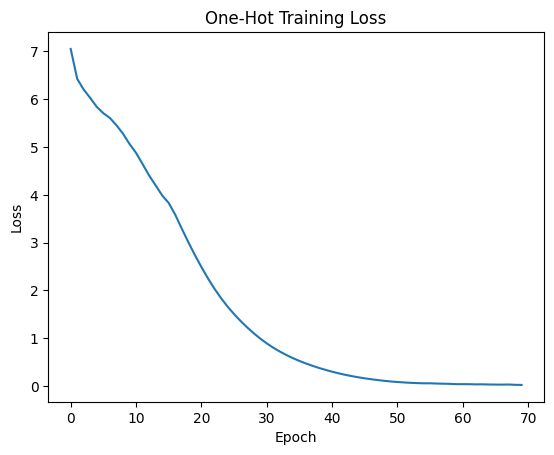

In [9]:
onehot_model = OneHotRNN(vocab_size, 128)
onehot_losses, onehot_time = train_model(onehot_model, "onehot", epochs=70)

plt.figure()
plt.plot(onehot_losses)
plt.title("One-Hot Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Training EMBEDDING MODEL

Epoch 1, Loss: 7.0826
Epoch 2, Loss: 6.1722
Epoch 3, Loss: 5.7738
Epoch 4, Loss: 5.4135
Epoch 5, Loss: 5.0595
Epoch 6, Loss: 4.7423
Epoch 7, Loss: 4.4072
Epoch 8, Loss: 4.1402
Epoch 9, Loss: 3.8187
Epoch 10, Loss: 3.4848
Epoch 11, Loss: 3.1880
Epoch 12, Loss: 2.9133
Epoch 13, Loss: 2.6554
Epoch 14, Loss: 2.4127
Epoch 15, Loss: 2.1849
Epoch 16, Loss: 1.9722
Epoch 17, Loss: 1.7755
Epoch 18, Loss: 1.5950
Epoch 19, Loss: 1.4299
Epoch 20, Loss: 1.2790
Epoch 21, Loss: 1.1418
Epoch 22, Loss: 1.0181
Epoch 23, Loss: 0.9060
Epoch 24, Loss: 0.8043
Epoch 25, Loss: 0.7121
Epoch 26, Loss: 0.6291
Epoch 27, Loss: 0.5550
Epoch 28, Loss: 0.4895
Epoch 29, Loss: 0.4311
Epoch 30, Loss: 0.3789
Epoch 31, Loss: 0.3332
Epoch 32, Loss: 0.2925
Epoch 33, Loss: 0.2569
Epoch 34, Loss: 0.2273
Epoch 35, Loss: 0.2006
Epoch 36, Loss: 0.1777
Epoch 37, Loss: 0.1574
Epoch 38, Loss: 0.1396
Epoch 39, Loss: 0.1244
Epoch 40, Loss: 0.1113
Epoch 41, Loss: 0.1019
Epoch 42, Loss: 0.0926
Epoch 43, Loss: 0.0849
Epoch 44, Loss: 0.07

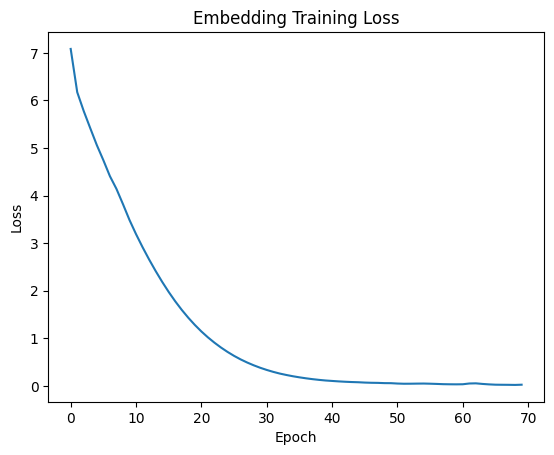

In [10]:
embedding_model = EmbeddingRNN(vocab_size, 100, 128)
embedding_losses, embedding_time = train_model(embedding_model, "embedding", epochs=70)

plt.figure()
plt.plot(embedding_losses)
plt.title("Embedding Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Loss Comparison

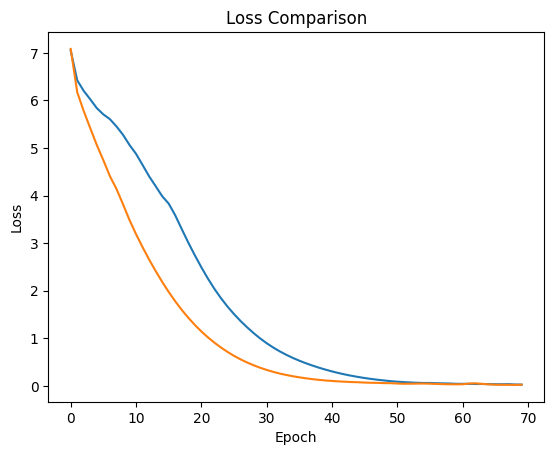

In [11]:
plt.figure()
plt.plot(onehot_losses)
plt.plot(embedding_losses)
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

## Train Time Comparison

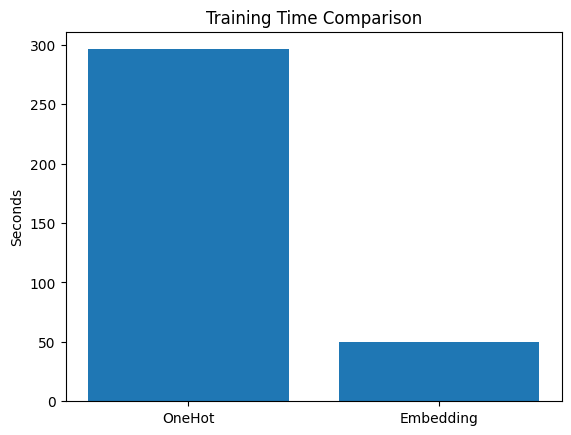

OneHot Time: 296.33116364479065
Embedding Time: 49.75041127204895


In [12]:
plt.figure()
plt.bar(["OneHot", "Embedding"], [onehot_time, embedding_time])
plt.title("Training Time Comparison")
plt.ylabel("Seconds")
plt.show()

print("OneHot Time:", onehot_time)
print("Embedding Time:", embedding_time)

## Text generation

In [14]:
def generate_text(model, start_words, max_len=50, mode="embedding"):
    model.eval()
    words_gen = start_words.copy()
    
    for _ in range(max_len):
        seq = words_gen[-sequence_length:]
        idx_seq = [word2idx[w] for w in seq]
        x = torch.tensor([idx_seq])
        
        if mode == "onehot":
            x = one_hot_batch(x)
        else:
            x = x.to(device)
        
        with torch.no_grad():
            output = model(x)
            probs = torch.softmax(output, dim=1)
            next_word = torch.argmax(probs).item()
        
        words_gen.append(idx2word[next_word])
    
    return " ".join(words_gen)

print("\nGenerated Text (OneHot):")
print(generate_text(onehot_model, words[:sequence_length], mode="onehot"))

print("\nGenerated Text (Embedding):")
print(generate_text(embedding_model, words[:sequence_length], mode="embedding"))



Generated Text (OneHot):
text o my luves like a melodie thats sweetly playd in tune as fair art thou my bonnie lass so deep in luve am i and i will luve thee still my dear till the the seas gang dry till a the seas gang dry till a the seas gang dry till a the seas

Generated Text (Embedding):
text o my luves like a red red rose thats newly sprung in june o my luves like the melodie thats sweetly playd in tune as fair art thou my bonnie lass so deep in luve am i and i will luve thee still my dear while the sands o life shall run and fare
